import libraries an load data

In [11]:
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
tsla = pd.read_csv(
    "../data/processed/TSLA.csv",
    index_col=0,
    parse_dates=True
)

tsla.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


the close price

In [12]:
tsla = tsla[["Close"]]

train/test split

In [13]:
tsla = tsla.sort_index()
train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

check sizes

In [14]:
print(train.shape)
print(test.shape)

(2516, 1)
(372, 1)


visualize the split

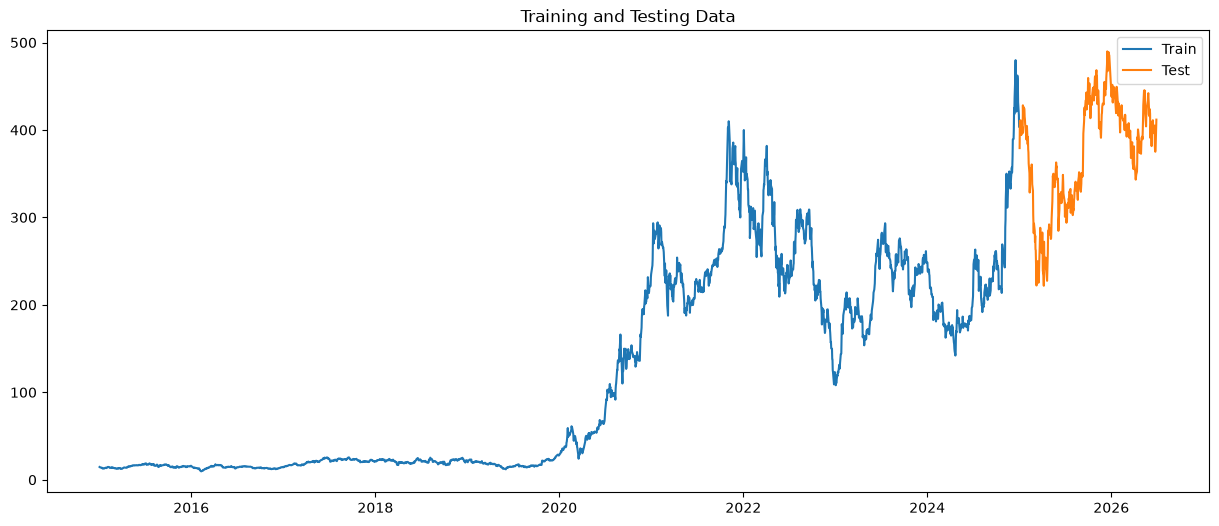

In [15]:
plt.figure(figsize=(15, 6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.legend()
plt.title("Training and Testing Data")
plt.show()

In [16]:
auto_model = auto_arima(
    train["Close"],
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.71 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.474 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        18:26:13   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    